Here we pretrain and train a model for few steps to test architectures

In [1]:
from tinyreasoner.training.performance import performance_tweaks
performance_tweaks(True)

import matplotlib.pyplot as plt
from tinyreasoner.training.training import Pretrainer, SFTTrainer
from tinyreasoner.optim import SPlus
from tinyreasoner.models import models

import torch
from torch import nn
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = models.LSTM_5L_1H_154_1m()


print(model.n_params())
# model.load_state_dict(torch.load("LSTM_1L_1H_342_1m-PT-natural_reasoning-1e-1-0.8606054186820984.pt",))
model

980447


LSTM_5L_1H_154_1m(
  (embedding): Embedding(83, 154)
  (rnn): LSTM(154, 154, num_layers=5, batch_first=True)
  (head): Sequential(
    (0): Dropout(p=0, inplace=False)
    (1): Linear(in_features=154, out_features=83, bias=True)
  )
)

# Pretrain

In [2]:
from tinyreasoner.datasets import natural_reasoning, tinybrain_pretrain
dataset = tinybrain_pretrain.load(200_000)
dataset[0]

'a combination of one or more elementary reaction steps which start with the appropriate reactants and end with the appropriate product(s)\na description of the path, or sequence of steps, by which a reaction occurs\na description of the path that a reaction takes\na detailed description of how a chemical reaction occurs\na detailed description of the way a reaction occurs and is based on the known experimental data about the reaction\na detailed (theoretical) description of how we think the chemical reaction proceeds\na series of elementary reactions or elementary steps that lead from reactants to products\na set of steps at the molecular level\na step by step description of the separate steps that occur during a chemical reaction\na stepwise description of the reaction path\nmechanism. A list of all elementary reactions that occur in the course of an overall chemical reaction.\nIn chemistry, a reaction mechanism is the step by step sequence of elementary reactions by which overall ch

In [ ]:
n_steps = 20_000
lr = 1e-1

optimizer = SPlus(
    model,
    lr = lr,
    weight_decay = 1e-1,
)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=lr, total_steps=n_steps, cycle_momentum=False, pct_start=0.1)

trainer = Pretrainer(
    dataset = dataset,
    model = model,
    sequence_length = 2048,
    optimizer = optimizer,
    scheduler = scheduler,
    batch_size = 128,
    test_batch_size = 128,
    test_every = 1000,
    test_steps = 100,
    data_device = 'cpu'
).run(n_steps)

model.load_state_dict(trainer.best_state_dict)

plt.plot(*zip(*trainer.logger["train loss"].items()), label="train")
plt.plot(*zip(*trainer.logger["test loss"].items()), label="test loss")
plt.plot(*zip(*trainer.logger["test loss ema"].items()), label="test loss (EMA)")
plt.grid(which='both')
plt.legend()
plt.show()

  0%|          | 0/20000 [00:00<?, ?it/s]

input:
'hite blood cells to attack the invaders.\n<|UNK|>8220<|UNK|><|UNK|>Your spleen is often on the <|UNK|>8216<|UNK|><|UNK|>front lines<|UNK|>8217<|UNK|><|UNK|> of your body,<|UNK|>8221<|UNK|><|UNK|> the Children<|UNK|>8217<|UNK|><|UNK|>s Hospital of Pittsburgh writes on its website. <|UNK|>8220<|UNK|><|UNK|>In fact, your spleen is a busy organ <|UNK|>8211<|UNK|><|UNK|> especially considering its small size.<|UNK|>8221<|UNK|><|UNK|>\nThe Importance of Spleen Health\nBecause the spleen is such a crucial part of the immune system, it<|UNK|>8217<|UNK|><|UNK|>s of utter importance to maintain its health. <|UNK|>8220<|UNK|><|UNK|>The majority of functional gastrointestinal disorders, such as poor appetite, dyspepsia, diarrhea, and constipation result from a weak spleen organ system,<|UNK|>8221<|UNK|><|UNK|> says Professor Bian Zhaoxiang, MD, director of the clinical division of Baptist University<|UNK|>8217<|UNK|><|UNK|>s School of Chinese Medicine. Additionally, a poorly functioning or

  0%|          | 48/20000 [01:17<2:14:52,  2.47it/s, train_loss=4.3824, test_loss=4.4093, best=4.4093] 

In [8]:
text = "What is 100 - 33?"
tokens = torch.tensor(model.tokenizer.encode_text(text), device=device)
model.tokenizer.decode(model.predict(tokens, 100).output_tokens)

'\nThe State Commission Company County Commission Institute for Science Commission Act 1999.'

In [9]:
torch.save(model.state_dict(), f"{model.__class__.__name__}-AT-PT-1e-1-{trainer.best_test_loss}.pt")

# Train

In [4]:
from tinyreasoner.datasets import (
    generate_reasoning,
    generate_dataset,
    math_500,
    math_dataset_elementary_school,
    xlam_function_calling_60k,

    synthetic_code_reasoning,
    synthetic_logic,
    synthetic_math,
    synthetic_meta_knowledge,
    synthetic_probability,
    synthetic_puzzles,
    synthetic_string,
    synthetic_tool_calling,
    synthetic_word_problems,
    synthetic_expression_trees,
    synthetic_basic,
)
from tinyreasoner import chat_api

synthetic_datasets = [
    synthetic_code_reasoning,
    synthetic_logic,
    synthetic_math,
    synthetic_meta_knowledge,
    synthetic_probability,
    synthetic_puzzles,
    synthetic_string,
    synthetic_tool_calling,
    synthetic_word_problems,
    synthetic_expression_trees,
    synthetic_basic,
]

dataset = generate_reasoning.load()
print(f'n reasoning: {len(dataset )}')

dataset = (
    dataset
    + generate_dataset.load()
    + math_dataset_elementary_school.load()
    + math_500.load()
    + xlam_function_calling_60k.load()[:10_000]
)
print(f'n reasoning + real: {len(dataset)}')

for ds in synthetic_datasets:
    dataset += ds.load(9_000, seed=None)

dataset = chat_api.deduplicate(dataset)
for chat in dataset:
    chat_api.validate_chat(chat)


print(f'n final: {len(dataset)}')

n reasoning: 75349
n reasoning + real: 99546
n final: 158422


  0%|          | 0/100000 [00:00<?, ?it/s]

input:
'<|USER_MESSAGE|>What is the base six equivalent of $999_{10}$?. Only include the answer in your response.<|END|><|ASSISTANT_MESSAGE|><|THINK|>'
output:
'angere is a significant increase in the same process of the sea level. The state of the Constitution is a strong power to the Constitution of American American Community Council (ASCE) and the Constitution of Congress and Congress and Social Sciences and Conservation Council and the Constitution of Congress Conservation Council (NASA) and Constitution Control and State University Council (NASA) and Congress Conservation Commission (NASA) and Congress Conservation Commission (ICEN) and State University of America and State Council and the Constitution Control and State University Council (NCA) and State University Council (NASA) and Congress Conservation Commission (NASA) and Congress Committee and Science Committee and Conservation Control and Control and Standards of Conservation Control and Program Activities Act (ASCE) Stude

  1%|          | 1000/100000 [01:46<1:52:37, 14.65it/s, train_loss=0.99362, test_loss=1.4946, best=1.4946]

input:
'<|USER_MESSAGE|>Is it true that 12 is NOT even? Only include the answer in your response.<|END|><|ASSISTANT_MESSAGE|><|THINK|>'
output:
'I need to analyze the chat history to understand the context and then consider the context and then consider the context and then consider the context and then consider the context and then consider the context and then consider the context and then consider the context and then consider the context and then consider the context and then consider the context and then consider the context and then consider the context and then recall the context. The reasoning is asking for a conversation to understand the context and then consider the context and the reasoning is asking for a provided relationship between the context and then recall the context. The user is asking for a conversation to understand the context and then consider the context and then consider the context and then consider the context and then consider the context and then consider

  1%|          | 1001/100000 [02:01<107:12:07,  3.90s/it, train_loss=1.1982, test_loss=1.1607, best=0.98014]

...

input:
'<|USER_MESSAGE|>What is the XOR of all integers from 27 to 47 inclusive? Only include the answer in your response.<|END|><|ASSISTANT_MESSAGE|>'
output:
'12<|END|>'
input:
'<|TOOL_DEFINITION|>{"name": "convert_currency", "description": "Convert an amount from one currency to another.", "parameters": {"type": "object", "properties": {"amount": {"type": "number", "description": "Amount to convert"}, "from_currency": {"type": "string", "description": "Source currency code (e.g. USD)"}, "to_currency": {"type": "string", "description": "Target currency code (e.g. EUR)"}}, "required": ["amount", "from_currency", "to_currency"]}}<|END|><|USER_MESSAGE|>Convert 783 JPY to CAD.<|END|><|ASSISTANT_MESSAGE|>'
output:
'<|TOOL_CALL|>convert_currency<|TOOL_CALL|>{"amount": 344, "from_currency": "GBP", "to_currency": "EUR"}<|END|>'


 36%|███▋      | 36352/100000 [59:17<1:25:44, 12.37it/s, train_loss=0.64713, test_loss=0.59284, best=0.59284] 

input:
'<|USER_MESSAGE|>remove all characters from the string ",on7r48dc ,3i4192632.c7n7 .2r" that are not present in string "IMf7W"\nonly include the answer in your response<|END|><|ASSISTANT_MESSAGE|><|THINK|>'
output:
'I need to analyze the chat history to understand the context. I should look for patterns in the conversation and identify all necessary characters in the string "TSWSCTSSEGPOT". I will go through the string step by step to find the correct answer. The goal is to remove all characters from the string "ABCCDWSFQMVVGEGMOSDESWQQEESESWSSFQVESEVESESETTSSECSETANWSSFT". The correct answer is "TSLA". This step ensures the output matches the required format.<|THINK|>"ECSESVASSDESVETASSTASSTASSTASSTANSTASSTASSTASSTASSTASS"<|END|>'


 36%|███▋      | 36352/100000 [59:45<1:44:37, 10.14it/s, train_loss=0.64713, test_loss=0.59284, best=0.59284]

input:
'<|USER_MESSAGE|>Convert to uppercase: "yellow igloo" Only include the answer in your response.<|END|><|ASSISTANT_MESSAGE|>'
output:
'TIDE WREN EMBER DELTA<|END|>'


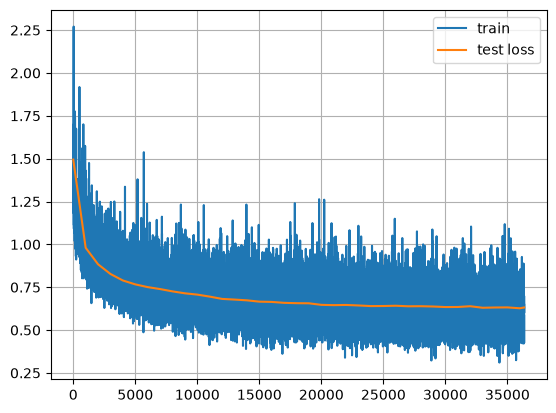

In [5]:
model.load_state_dict(torch.load("LSTM_1L_5H_280_1m-AT-PT-1e-1-1.134270429611206.pt"))

n_steps = 100_000
lr = 1e-1

optimizer = SPlus(
    model,
    lr = lr,
    weight_decay = 1e-2,
)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=lr, total_steps=n_steps, cycle_momentum=False, pct_start=0.1)

trainer = SFTTrainer(
    dataset = dataset,
    model = model,
    optimizer = optimizer,
    scheduler = scheduler,
    batch_size = 24,
    test_batch_size = 64,
    test_every = 1000,
    device = device,
    data_device = 'cpu',
).run(n_steps)

model.load_state_dict(trainer.best_state_dict)

plt.plot(*zip(*trainer.logger["train loss"].items()), label="train")
plt.plot(*zip(*trainer.logger["test loss"].items()), label="test loss")
plt.grid(which='both')
plt.legend()
plt.show()

In [71]:
text = "3+2=?"
model.tokenizer.decode(model.predict(text, 4096, think=False).output_tokens)

'4<|END|>'

In [72]:
torch.save(model.state_dict(), f"{model.__class__.__name__}-AT-SFT-1e-1-{trainer.best_test_loss}.pt")